# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV936"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv936')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv936/lv936-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV936,gene_band
0,HEXB,5.493554,5q13.3
1,ALG11,5.140608,13q14.3
2,CBR1,4.992476,21q22.12
3,PATL1,4.842792,11q12.1
4,MFGE8,4.395033,15q26.1
5,ABL1,3.552782,9q34.12
6,S1PR3,3.521828,9q22.1
7,GYS1,3.141752,19q13.33
8,AZI2,3.084208,3p24.1
9,DLG5,2.986320,10q22.3


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-26 17:21:58,291 - numexpr.utils] INFO: Note: NumExpr detected 48 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-26 17:21:58,292 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP012461, SRP055569, SRP060416, SRP042161, SRP033135, SRP050499, SRP057196, SRP066834, SRP063059, SRP059379, SRP057205, SRP003726, SRP064464, SRP013363, SRP050087, SRP062177, SRP055153, SRP019994, SRP055513, SRP017575, SRP020470, SRP039348, SRP007338, SRP051606, SRP058773, SRP007461, SRP012557, SRP012098, SRP015449, SRP015668, SRP050497, SRP042620, SRP009266, SRP052740, SRP063840, SRP067529, SRP002487, SRP059775, SRP043960, SRP034666, SRP017959, SRP036821, SRP007481, SRP006575, SRP050374, SRP059035, SRP014320, SRP011578, SRP049593, SRP040243, SRP030617, SRP009276, SRP026537, SRP002326, SRP019810, SRP020493, SRP034543, SRP004847, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (54 != 58)
  warnings.warn(


In [12]:
lv_data.shape

(7061, 99)

In [13]:
lv_data.head()

cell type     treatment day  \
project   run                                                   
SRP012461 SRR490216  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490217  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490218  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490219  Mesenchymal Stem Cells    Noninduced  d0   
          SRR490220  Mesenchymal Stem Cells  Adipogenesis  d1   

                    patient code name barcode tonsil donor facs gating  \
project   run                                                            
SRP012461 SRR490216         Charlotte  TTTAGG          NaN         NaN   
          SRR490217         Charlotte  TTTAGG          NaN         NaN   
          SRR490218         Charlotte  TTTAGG          NaN         NaN   
          SRR490219         Charlotte  TTTAGG          NaN         NaN   
          SRR490220         Charlotte  ATTCCA          NaN         NaN   

                    cell line patient id subtype  ... passage  \
project   run                                     ...           
SRP012461 SRR490216       NaN        NaN     NaN  ...     NaN   
          SRR490217       NaN        NaN     NaN  ...     NaN   
          SRR490218       NaN        NaN     NaN  ...     NaN   
          SRR490219       NaN        NaN     NaN  ...     NaN   
          SRR490220       NaN        NaN     NaN  ...     NaN   

                    cdna synthesis method library construction method  \
project   run                                                           
SRP012461 SRR490216                   NaN                         NaN   
          SRR490217                   NaN                         NaN   
          SRR490218                   NaN                         NaN   
          SRR490219                   NaN                         NaN   
          SRR490220                   NaN                         NaN   

                    growth stage rna subtype dsn time transfection rna type  \
project   run                                                                 
SRP012461 SRR490216          NaN         NaN      NaN          NaN      NaN   
          SRR490217          NaN         NaN      NaN          NaN      NaN   
          SRR490218          NaN         NaN      NaN          NaN      NaN   
          SRR490219          NaN         NaN      NaN          NaN      NaN   
          SRR490220          NaN         NaN      NaN          NaN      NaN   

                    antibody vender     LV936  
project   run                                  
SRP012461 SRR490216             NaN -0.009944  
          SRR490217             NaN  0.011288  
          SRR490218             NaN  0.004450  
          SRR490219             NaN  0.022883  
          SRR490220             NaN  0.011310  

[5 rows x 99 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

day                            0.267592
patient code name              0.267592
barcode                        0.267592
treatment                      0.258201
cell type                      0.026281
status                         0.004887
disease model                  0.004881
reprogramming vector           0.003496
iPSc                           0.003496
time                           0.003190
cell line stably expressing    0.002314
par-clip antibody              0.002314
culture medium                 0.002314
patient id                     0.002114
cell marker                    0.001996
facs gating                    0.001957
tonsil donor                   0.001957
experiment_sample_name         0.001926
c1 chip id                     0.001926
antibody vender                0.001920
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell type         0.026281
tissue            0.001172
tissue subtype    0.000833
cell line         0.000734
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell type",
    "tissue",
    "tissue subtype",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell type  \
project   run                                                             
SRP012461 SRR490464                                         Fibroblasts   
          SRR490465                                         Fibroblasts   
          SRR490466                                         Fibroblasts   
          SRR490467                                         Fibroblasts   
SRP055569 SRR1821384                             U87 human glioma cells   
SRP060416 SRR2088294                       tonsil Innate lymphoid cells   
SRP055569 SRR2019138  mixture of U87 human glioma cells and WI-38 hu...   
SRP042161 SRR1294653                                       Glioblastoma   
          SRR1294994                                       Glioblastoma   
SRP033135 SRR1033243             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR1821392                             U87 human glioma cells   
          SRR1821530  mixture of U87 human glioma cells and MCF10a h...   
SRP050499 SRR2013741                                                NaN   
SRP042161 SRR1295340                             Gliomasphere Cell Line   
SRP055569 SRR1821528  mixture of U87 human glioma cells and MCF10a h...   
          SRR2019112  mixture of U87 human glioma cells and WI-38 hu...   
SRP033135 SRR1033029             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057196 SRR1974836                                   oligodendrocytes   
SRP066834 SRR2967815                                                NaN   
SRP057196 SRR1974755                                        endothelial   
SRP060416 SRR2088213                       tonsil Innate lymphoid cells   
SRP042161 SRR1295029                                       Glioblastoma   
          SRR1294581                                       Glioblastoma   
SRP060416 SRR2088106                       tonsil Innate lymphoid cells   
SRP057196 SRR1974616                                   oligodendrocytes   

                               tissue tissue subtype cell line     LV936  
project   run                                                             
SRP012461 SRR490464               NaN            NaN       NaN  9.306189  
          SRR490465               NaN            NaN       NaN  3.216764  
          SRR490466               NaN            NaN       NaN  2.367309  
          SRR490467               NaN            NaN       NaN  0.757934  
SRP055569 SRR1821384              NaN            NaN       NaN  0.451664  
SRP060416 SRR2088294              NaN            NaN       NaN  0.413136  
SRP055569 SRR2019138              NaN            NaN       NaN  0.404176  
SRP042161 SRR1294653              NaN            NaN       NaN  0.378381  
          SRR1294994              NaN            NaN       NaN  0.372762  
SRP033135 SRR1033243              NaN            NaN       NaN  0.338669  
SRP055569 SRR1821392              NaN            NaN       NaN  0.315977  
          SRR1821530              NaN            NaN       NaN  0.312675  
SRP050499 SRR2013741              NaN            NaN       NaN  0.310382  
SRP042161 SRR1295340              NaN            NaN      CSC8  0.299766  
SRP055569 SRR1821528              NaN            NaN       NaN  0.291407  
          SRR2019112              NaN            NaN       NaN  0.288929  
SRP033135 SRR1033029              NaN            NaN       NaN  0.283837  
SRP057196 SRR1974836           cortex            NaN       NaN  0.258825  
SRP066834 SRR2967815  Fetal neocortex            NaN       NaN  0.244231  
SRP057196 SRR1974755           cortex            NaN       NaN  0.243890  
SRP060416 SRR2088213              NaN            NaN       NaN  0.236573  
SRP042161 SRR1295029              NaN            NaN       NaN  0.232713  
          SRR1294581              NaN            NaN       NaN  0.229193  
SRP060416 SRR2088106              NaN            NaN       NaN  0.225135  
SRP057196 SRR1974616           cortex            NaN       NaN  0.218803

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

cell type  \
project   run                                                             
SRP055569 SRR1821698                   MCF10a human breast cancer cells   
SRP063059 SRR2225757                                  dermal fibroblast   
          SRR2225755                                  dermal fibroblast   
SRP060416 SRR2088417                       tonsil Innate lymphoid cells   
SRP063059 SRR2225756                                  dermal fibroblast   
SRP055569 SRR1821513  mixture of U87 human glioma cells and MCF10a h...   
SRP063059 SRR2225767                                  dermal fibroblast   
SRP060416 SRR2088232                       tonsil Innate lymphoid cells   
          SRR2088135                       tonsil Innate lymphoid cells   
SRP063059 SRR2225768                                  dermal fibroblast   
SRP057196 SRR1974865                                         astrocytes   
SRP059379 SRR2060560                       iPSC-derived cortical neuron   
SRP042161 SRR1294544                                       Glioblastoma   
SRP066834 SRR2967802                                                NaN   
          SRR2967791                                                NaN   
SRP060416 SRR2088100                       tonsil Innate lymphoid cells   
SRP066834 SRR2967486                                                NaN   
SRP033135 SRR1033235             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057196 SRR1975008                                    fetal_quiescent   
SRP063059 SRR2225769                                  dermal fibroblast   
SRP042161 SRR1294920                                       Glioblastoma   
SRP055569 SRR2019144  mixture of U87 human glioma cells and WI-38 hu...   
SRP042161 SRR1294502                                       Glioblastoma   
SRP033135 SRR1033263             Human Skeletal Muscle Myoblasts (HSMM)   
SRP042161 SRR1294652                                       Glioblastoma   

                                                                 tissue  \
project   run                                                             
SRP055569 SRR1821698                                                NaN   
SRP063059 SRR2225757                                                NaN   
          SRR2225755                                                NaN   
SRP060416 SRR2088417                                                NaN   
SRP063059 SRR2225756                                                NaN   
SRP055569 SRR1821513                                                NaN   
SRP063059 SRR2225767                                                NaN   
SRP060416 SRR2088232                                                NaN   
          SRR2088135                                                NaN   
SRP063059 SRR2225768                                                NaN   
SRP057196 SRR1974865                                             cortex   
SRP059379 SRR2060560                                                NaN   
SRP042161 SRR1294544                                                NaN   
SRP066834 SRR2967802                                    Fetal neocortex   
          SRR2967791                                    Fetal neocortex   
SRP060416 SRR2088100                                                NaN   
SRP066834 SRR2967486  Microdissected cortical-like ventricle from ce...   
SRP033135 SRR1033235                                                NaN   
SRP057196 SRR1975008                                             cortex   
SRP063059 SRR2225769                                                NaN   
SRP042161 SRR1294920                                                NaN   
SRP055569 SRR2019144                                                NaN   
SRP042161 SRR1294502                                                NaN   
SRP033135 SRR1033263                                                NaN   
SRP042161 SRR1294652                                                NaN   

          

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "cell type",
    "tissue",
    "tissue subtype",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

cell type  \
project   run                                                             
SRP012461 SRR490464                                         Fibroblasts   
          SRR490465                                         Fibroblasts   
          SRR490466                                         Fibroblasts   
          SRR490467                                         Fibroblasts   
SRP055569 SRR1821384                             U87 human glioma cells   
SRP060416 SRR2088294                       tonsil Innate lymphoid cells   
SRP055569 SRR2019138  mixture of U87 human glioma cells and WI-38 hu...   
SRP042161 SRR1294653                                       Glioblastoma   
          SRR1294994                                       Glioblastoma   
SRP033135 SRR1033243             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR1821392                             U87 human glioma cells   
          SRR1821530  mixture of U87 human glioma cells and MCF10a h...   
SRP050499 SRR2013741                                    NOT CATEGORIZED   
SRP042161 SRR1295340                             Gliomasphere Cell Line   
SRP055569 SRR1821528  mixture of U87 human glioma cells and MCF10a h...   
          SRR2019112  mixture of U87 human glioma cells and WI-38 hu...   
SRP033135 SRR1033029             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057196 SRR1974836                                   oligodendrocytes   
SRP066834 SRR2967815                                    Fetal neocortex   
SRP057196 SRR1974755                                        endothelial   

                         LV936  
project   run                   
SRP012461 SRR490464   9.306189  
          SRR490465   3.216764  
          SRR490466   2.367309  
          SRR490467   0.757934  
SRP055569 SRR1821384  0.451664  
SRP060416 SRR2088294  0.413136  
SRP055569 SRR2019138  0.404176  
SRP042161 SRR1294653  0.378381  
          SRR1294994  0.372762  
SRP033135 SRR1033243  0.338669  
SRP055569 SRR1821392  0.315977  
          SRR1821530  0.312675  
SRP050499 SRR2013741  0.310382  
SRP042161 SRR1295340  0.299766  
SRP055569 SRR1821528  0.291407  
          SRR2019112  0.288929  
SRP033135 SRR1033029  0.283837  
SRP057196 SRR1974836  0.258825  
SRP066834 SRR2967815  0.244231  
SRP057196 SRR1974755  0.243890

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Fibroblasts',
 'U87 human glioma cells',
 'tonsil Innate lymphoid cells',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells',
 'Glioblastoma']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

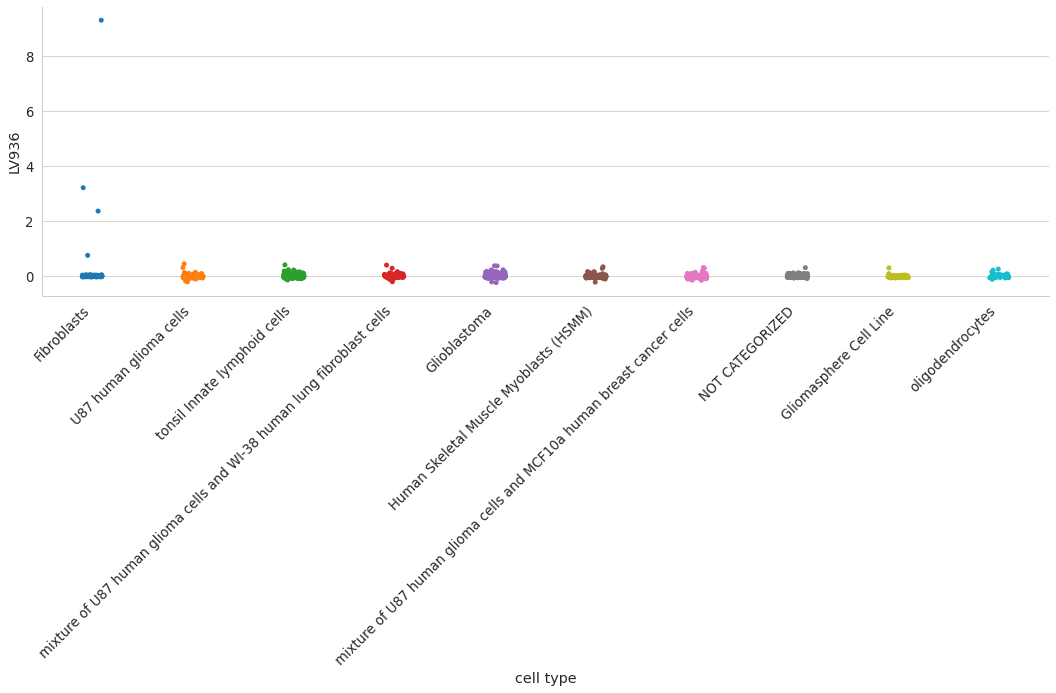

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Fibroblasts")
    ]
    display(_tmp.head(20))

cell type     LV936
project   run                             
SRP012461 SRR490464  Fibroblasts  9.306189
          SRR490465  Fibroblasts  3.216764
          SRR490466  Fibroblasts  2.367309
          SRR490467  Fibroblasts  0.757934
          SRR490452  Fibroblasts  0.055323
          SRR490455  Fibroblasts  0.052983
          SRR490454  Fibroblasts  0.045950
          SRR490524  Fibroblasts  0.041171
          SRR490566  Fibroblasts  0.040937
          SRR490512  Fibroblasts  0.035935
          SRR490424  Fibroblasts  0.035791
          SRR490532  Fibroblasts  0.035419
          SRR490413  Fibroblasts  0.034940
          SRR490458  Fibroblasts  0.032838
          SRR490469  Fibroblasts  0.032720
          SRR490471  Fibroblasts  0.032543
          SRR490470  Fibroblasts  0.032276
          SRR490525  Fibroblasts  0.031941
          SRR490444  Fibroblasts  0.031718
          SRR490533  Fibroblasts  0.031416

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP012461"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell type       treatment   day  \
project   run                                                       
SRP012461 SRR490464             Fibroblasts    Osteogenesis    d3   
          SRR490465             Fibroblasts    Osteogenesis    d3   
          SRR490466             Fibroblasts    Osteogenesis    d3   
          SRR490467             Fibroblasts    Osteogenesis    d3   
          SRR490310  Mesenchymal Stem Cells      Noninduced    d0   
          SRR490229  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490257  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490261  Mesenchymal Stem Cells    Adipogenesis    d4   
          SRR490260  Mesenchymal Stem Cells    Adipogenesis    d4   
          SRR490259  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490452             Fibroblasts    Adipogenesis    d7   
          SRR490455             Fibroblasts    Adipogenesis    d7   
          SRR490256  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490263  Mesenchymal Stem Cells    Adipogenesis    d4   
          SRR490262  Mesenchymal Stem Cells    Adipogenesis    d4   
          SRR490231  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490230  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490454             Fibroblasts    Adipogenesis    d7   
          SRR490343  Mesenchymal Stem Cells      Noninduced    d0   
          SRR490266  Mesenchymal Stem Cells    Adipogenesis    d5   
          SRR490267  Mesenchymal Stem Cells    Adipogenesis    d5   
          SRR490524             Fibroblasts  Chondrogenesis    d2   
          SRR490566             Fibroblasts  Chondrogenesis    d4   
          SRR490264  Mesenchymal Stem Cells    Adipogenesis    d5   
          SRR490336  Mesenchymal Stem Cells    Osteogenesis    d7   
          SRR490322  Mesenchymal Stem Cells    Osteogenesis    d3   
          SRR490512             Fibroblasts    Osteogenesis    d7   
          SRR490424             Fibroblasts    Adipogenesis    d7   
          SRR490532             Fibroblasts  Chondrogenesis    d4   
          SRR490413             Fibroblasts    Adipogenesis    d4   
          SRR490320  Mesenchymal Stem Cells    Osteogenesis    d3   
          SRR490458             Fibroblasts      Noninduced    d0   
          SRR490469             Fibroblasts    Osteogenesis    d4   
          SRR490332  Mesenchymal Stem Cells    Osteogenesis    d6   
          SRR490471             Fibroblasts    Osteogenesis    d4   
          SRR490273  Mesenchymal Stem Cells    Adipogenesis    d7   
          SRR490470             Fibroblasts    Osteogenesis    d4   
          SRR490525             Fibroblasts  Chondrogenesis    d2   
          SRR490444             Fibroblasts    Adipogenesis    d4   
          SRR490321  Mesenchymal Stem Cells    Osteogenesis    d3   
          SRR490533             Fibroblasts  Chondrogenesis    d4   
          SRR490527             Fibroblasts  Chondrogenesis    d2   
          SRR490258  Mesenchymal Stem Cells    Adipogenesis    d3   
          SRR490514             Fibroblasts    Osteogenesis    d7   
          SRR490323  Mesenchymal Stem Cells    Osteogenesis    d3   
          SRR490265  Mesenchymal Stem Cells    Adipogenesis    d5   
          SRR490422             Fibroblasts    Adipogenesis    d6   
          SRR490453             Fibroblasts    Adipogenesis    d7   
          SRR490599                    none           Blank  none   
          SRR490342  Mesenchymal Stem Cells      Noninduced    d0   
          SRR490338  Mesenchymal Stem Cells    Osteogenesis    d7   
          SRR490337  Mesenchymal Stem Cells    Osteogenesis    d7   
          SRR490294  Mesenchymal Stem Cells    Osteogenesis    d4   
          SRR490485             Fibroblasts      Noninduced    d0   
          SRR490281  Mesenchymal Stem Cells    Osteogenesis    d1   
          SRR490457             Fibroblasts      Noninduced    d0   
          SRR490534             

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.